In [ ]:
!pip install torch torchvision torchaudio matplotlib opencv-python scikit-learn

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shinitks","key":"e74853a637d47cfd08ff9099047a2764"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d divyanshrai/handwritten-signatures
!unzip -o handwritten-signatures.zip -d /content/signature_data

Dataset URL: https://www.kaggle.com/datasets/divyanshrai/handwritten-signatures
License(s): unknown
 83% 306M/370M [00:05<00:01, 51.0MB/s]
100% 370M/370M [00:05<00:00, 68.9MB/s]
Archive:  handwritten-signatures.zip
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100001.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100002.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100003.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100004.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100005.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100006.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100007.png  
  inflating: /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100008

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import cv2, os
from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

# ————————————————
# 1. Define transforms
# ————————————————
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((155, 220)),
    transforms.RandomRotation(3),
    transforms.RandomAffine(0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((155, 220)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ————————————————
# 2. Load datasets WITHOUT transforms
# ————————————————
paths = [
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset1",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset2",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset3",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset4"
]

raw_datasets = [
    datasets.ImageFolder(root=p)
    for p in paths
]

full_dataset = ConcatDataset(raw_datasets)

# ————————————————
# 3. Split train / test ONCE (fixed)
# ————————————————
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_subset, test_subset = torch.utils.data.random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # FIXED split
)

# ————————————————
# 4. Now wrap subsets with transforms
# ————————————————
class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_data = TransformWrapper(train_subset, train_transform)
test_data  = TransformWrapper(test_subset,  test_transform)

# ————————————————
# 5. Loaders
# ————————————————
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SignNet(nn.Module):
    def __init__(self):
        super(SignNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 19 * 27, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 2)  # 2 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        #print(x.shape)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = SignNet()
print(model)


SignNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65664, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Epoch [1/15], Loss: 0.7381
Epoch [2/15], Loss: 0.6936
Epoch [3/15], Loss: 0.6928
Epoch [4/15], Loss: 0.6930
Epoch [5/15], Loss: 0.6641
Epoch [6/15], Loss: 0.5915
Epoch [7/15], Loss: 0.5780
Epoch [8/15], Loss: 0.5072
Epoch [9/15], Loss: 0.5269
Epoch [10/15], Loss: 0.4618
Epoch [11/15], Loss: 0.4366
Epoch [12/15], Loss: 0.2874
Epoch [13/15], Loss: 0.2673
Epoch [14/15], Loss: 0.1961
Epoch [15/15], Loss: 0.1567


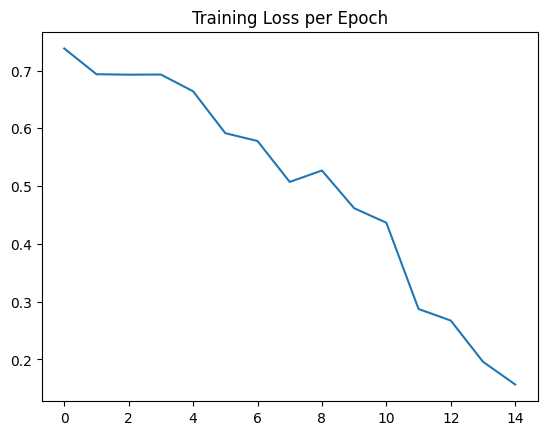

In [ ]:
num_epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
train_losses = []


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    train_losses.append(running_loss / len(train_loader))

plt.plot(train_losses)
plt.title("Training Loss per Epoch")
plt.show()


In [ ]:
#torch.save(model.state_dict(), "signnet_9722acc.pth")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")


Accuracy: 97.92%


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SignNet().to(device)
model.load_state_dict(torch.load("signnet_9722acc.pth", map_location=device))
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of loaded model: {accuracy:.2f}%")


Accuracy of loaded model: 97.92%


In [ ]:
!find /content -name "*.pth"


In [ ]:
from google.colab import files
files.upload()


Saving signnet_9722acc.pth to signnet_9722acc.pth
Buffered data was truncated after reaching the output size limit.